# Spacecraft Docking Problem (Rotating Target)

This notebook is a public companion for the 2-D docking benchmark in:

Meta-Reinforcement Learning for Robust and Non-greedy Control Barrier Functions in Spacecraft Proximity Operations (TAES submission). 

It covers:
- Problem definition and parameters (as used in the paper)
- Loading a **fixed Monte Carlo episode bank**
- Evaluating three controllers on the same episode set:
    1. **Untuned ICCBF**
    2. **MLP-tuned ICCBF**
    3. **RNN (LSTM) tuned ICCBF**
- Producing paper-style metrics and plots (thrust distributions, success rates, etc.)

Expected inputs (edit paths in `CONFIG`):
- `data/docking_episode_bank.npz`


![Docking Problem](images/docking.drawio.png)

This problem considers an autonomous planar rendezvous and docking scenario between a chaser spacecraft and a rotating docking port mounted on a rigid disk. The docking port rotates at a constant angular rate in the target’s local orbital frame. The objective is to safely guide the chaser from an initial separation of approximately 100 m to a small neighbourhood of the docking port while respecting thrust limits and safety constraints.

Dynamical Model
---------------

The relative motion is described in a planar LVLH frame. Define the state
\begin{equation}
x \triangleq
\begin{bmatrix}
p_x & p_y & v_x & v_y & \psi
\end{bmatrix}^{\!\top} \in \mathbb{R}^5,
\end{equation}
where $(p_x,p_y)$ and $(v_x,v_y)$ denote the chaser relative position and velocity, and $\psi$ is the angular position of the docking port on the rotating disk. The control input is
\begin{equation}
u \triangleq
\begin{bmatrix}
u_x & u_y
\end{bmatrix}^{\!\top} \in \mathbb{R}^2,
\qquad
\mathcal{U} = \{u \in \mathbb{R}^2 \,:\, \|u\| \le u_{\max}\}.
\end{equation}

The dynamics are given by the planar Hill--Clohessy--Wiltshire (HCW) equations augmented with the port rotation:
\begin{equation}
\begin{aligned}
\dot{p}_x &= v_x, \\
\dot{p}_y &= v_y, \\
\dot{v}_x &= 3n^2 p_x + 2n v_y + \frac{1}{m_c} u_x, \\
\dot{v}_y &= -2n v_x + \frac{1}{m_c} u_y, \\
\dot{\psi} &= \omega,
\end{aligned}
\end{equation}
where $m_c$ is the chaser mass, $n$ is the mean orbital motion, and $\omega$ is the constant angular rate of the docking port.

### Docking geometry

The docking port position is
\begin{equation}
p_d(\psi) =
\begin{bmatrix}
\rho \cos\psi \\
\rho \sin\psi
\end{bmatrix},
\end{equation}
where $\rho$ is the radius of the rotating disk. The relative position between the chaser and the docking port is
\begin{equation}
r_{c\!-\!p}(x) \triangleq
\begin{bmatrix}
p_x - \rho \cos\psi \\
p_y - \rho \sin\psi
\end{bmatrix}.
\end{equation}

### Safety constraint (line-of-sight)

To ensure safe approach, the chaser must remain within a line-of-sight (LOS) cone of half-angle $\gamma$ aligned with the docking axis. Define the docking-axis unit vector
\begin{equation}
\hat{e}(\psi) \triangleq
\begin{bmatrix}
\cos\psi \\
\sin\psi
\end{bmatrix}.
\end{equation}
The LOS constraint is written as
\begin{equation}
h_0(x) \triangleq
\frac{r_{c\!-\!p}(x)^{\top}\hat{e}(\psi)}{\|r_{c\!-\!p}(x)\|} - \cos\gamma
\;\ge\; 0.
\end{equation}
This constraint has relative degree greater than one with respect to the control input, motivating the use of input-constrained control barrier functions (ICCBFs).

### Goal-reaching objective (CLF)

A control Lyapunov function (CLF) is used to drive the chaser to the rotating docking port:
\begin{equation}
V(x) \triangleq
\left(v_x + \frac{p_x - \rho\cos\psi}{10}\right)^{\!2}
+
\left(v_y + \frac{p_y - \rho\sin\psi}{10}\right)^{\!2}.
\end{equation}
This CLF encourages velocity alignment with the docking port while reducing position error.

## Path setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[0]   # notebooks/ -> repo root
SRC = REPO_ROOT / "src"
sys.path.insert(0, str(SRC))  # do this once per kernel

## Initial State Distribution 


The initial states are drawn such that $\mathbf{x}_0 \in \mathcal{S}$, where $\mathcal{S}$ denotes the safe set defined by the line-of-sight (LOS) constraint in \eqref{eq:los_constraint}. Initial relative positions are selected within a bounded annulus centred on the target, with relative velocities chosen to be small and consistent with safe approach.

The episode parameter vector for the docking problem is defined as
\begin{equation}
    \mathbf{p} =
    \begin{bmatrix}
    m_c,\ \rho,\ \omega,\ u_{\max},\ \gamma,\ r
    \end{bmatrix}^{\!\top},
\end{equation}
where $m_c$ is the chaser mass, $\rho$ is the radius of the rotating docking disk, $\omega$ is the docking-port angular rate, $u_{\max}$ is the maximum available thrust magnitude, $\gamma$ is the LOS cone half-angle, and $r$ is the orbital radius used to compute the mean motion.

At the start of each episode, the parameters are sampled independently from a uniform distribution with bounds

\begin{equation}
    \mathbf{p}_{\min} =
    \begin{bmatrix}
    900.0,\ 2.28,\ 0.54^\circ/\mathrm{s},\ 0.2375,\ 9^\circ,\ 6093.9
    \end{bmatrix}^{\!\top},
\end{equation}

\begin{equation}
    \mathbf{p}_{\max} =
    \begin{bmatrix}
    1100.0,\ 2.64,\ 0.66^\circ/\mathrm{s},\ 0.2625,\ 11^\circ,\ 7448.1
    \end{bmatrix}^{\!\top}.
\end{equation}

These bounds correspond to approximately $\pm 10\%$ variation in the geometric and kinematic parameters $(\rho,\omega,\gamma)$ and in the chaser mass and thrust authority relative to their nominal values. The orbital radius range induces the corresponding variation in the mean orbital motion $n$ through Kepler’s third law.

All controllers are evaluated on the same fixed Monte Carlo episode bank, ensuring that each method is tested on identical initial conditions and parameter realisations.


In [2]:
from docking.make_fixed_ics import make_docking_episode_bank
make_docking_episode_bank()

Saved: ../src/data/docking/docking_episode_bank.npz
x0s: (5000, 5)
Inner-safe enforced.
h0_vec min/median: 0.2443475760673941 1.1732934234793824


['x0s', 'm_vec', 'rho_vec', 'om_vec', 'umax_vec', 'gamma_vec', 'r_vec', 'base_seed', 'seed_vec', 'enforce_inner_safe', 'h_margin', 'inner_band_frac', 'h0_vec', 'base_m', 'base_rho', 'base_om', 'base_umax', 'base_gamma', 'base_r', 'ranges']
x0s (5000, 5) float64
m_vec (5000,) float64
rho_vec (5000,) float64
om_vec (5000,) float64
umax_vec (5000,) float64
gamma_vec (5000,) float64
r_vec (5000,) float64
base_seed (1,) int64
seed_vec (5000,) int64
enforce_inner_safe (1,) int64
h_margin (1,) float64
inner_band_frac (1,) float64
h0_vec (5000,) float64
base_m (1,) float64
base_rho (1,) float64
base_om (1,) float64
base_umax (1,) float64
base_gamma (1,) float64
base_r (1,) float64
ranges (12,) float64


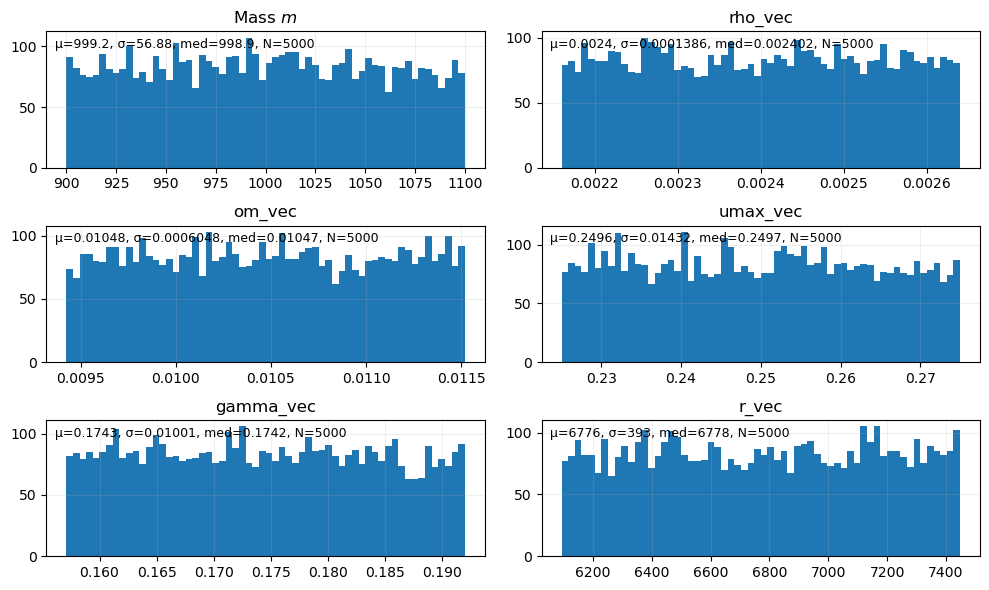

In [3]:
# plot the distributions 
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

D = np.load("../src/data/docking/docking_episode_bank.npz", allow_pickle=True)
print(D.files)
for k in D.files:
    v = D[k]
    print(k, getattr(v, "shape", None), v.dtype)

def plot_meta_params_from_bank(npz_path, bins=60):
    D = np.load(npz_path, allow_pickle=True)

    # if "meta_params" not in D.files:
    #     raise KeyError(f"'meta_params' not found. Keys are: {D.files}")

    # P = np.asarray(D).astype(float)
    P = np.asarray(D["m_vec"]).astype(float)
    names = D.tolist() if "meta_param_names" in D.files else ["m_vec","rho_vec","om_vec","umax_vec","gamma_vec","r_vec"]

    titles = {
        "m_vec": r"Mass $m$",
        "v0": r"Front speed $v_0$",
        "vmax": r"Target speed $v_{\max}$",
        "umax": r"Max thrust $u_{\max}$",
    }

    fig, axes = plt.subplots(3, 2, figsize=(10, 6))
    axes = axes.ravel()

    for i in range(6):
        ax = axes[i]
        # x = P[:, i]
      
        key = names[i]
        x =  np.asarray(D[key]).astype(float)
        ax.hist(x, bins=bins)
        ax.set_title(titles.get(key, key))
        mu, sd, med = np.mean(x), np.std(x), np.median(x)
        ax.text(0.02, 0.95, f"μ={mu:.4g}, σ={sd:.4g}, med={med:.4g}, N={x.size}",
                transform=ax.transAxes, va="top", fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_meta_params_from_bank("../src/data/docking/docking_episode_bank.npz", bins=60)

## Validate the determination of local Lipschitz constants via differential Algebra

To validate the quantities used in the control margin calculation, at each point $\boldsymbol{x}_{k,e}$ at time step $k$ and episode $e$,  true values of the $b_2$ , $L_fb_2$ and $L_g b_2$ are evaluated for a distribution of points within the local hyper-rectangle, centred around $x_{k,e}$. Their distances to the DA lower and bounds are shown below in the form of a violin plot

### Training

Here we train an MLP network and an LSTM network to determine the class-k function constants used in the ICCBF cascade. Note that the given settings are the ones used to generate the results in the paper. 
 
To run MLP training run the following code. Note that the training in the paper was done using GPUs (NVIDIA GeForce RTX 4090 ), over several days. 

In [4]:
from docking.train_DCNN import train_docking

model, log_dir = train_docking(
    # =========================
    # Nominal inputs (explicit)
    # =========================
    dt=0.5,
    total_episodes=200_000,
    approx_episode_len=200,   # set to your docking episode length in steps
    seed=123,

    # ---- Architecture ----
    layers=4,
    nodes=64,
    activation_fn="tanh",
    policy_type="PPO",        # <-- MLP PPO

    # ---- RL hyperparameters ----
    learning_rate=1e-4,
    lr_type="C",
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01,
    n_epochs=10,
    batch_size=64,
    n_steps=80,
    target_kl=0.02,

    # ---- Environment ----
    num_env=1,
    trainON=True,
    trainLoad=False,

    # ---- DA (only if your margins need it) ----
    init_da=True,
    da_order=4,
    da_vars=2,

    # ---- Logging ----
    root_log_dir="TrainedModels",
)

print("Saved in:", log_dir)

/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/site-packages/stable_baselines3/__init__.py", line 3, in <module>
    from stable_baselines3.a2c import A2C
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/site-packages/stable_baselines3/a2c/__init__.py", 

KeyboardInterrupt: 

Then to run the training process with the LSTM RNN network, run the following code.

In [ ]:
# Docking RNN (RecurrentPPO)
from docking.train_DCNN import train_docking

model, log_dir = train_docking(
    dt=0.5,
    total_episodes=200_000,
    approx_episode_len=200,
    seed=123,

    layers=4,
    nodes=64,
    activation_fn="tanh",
    policy_type="RNN",        # <-- LSTM RecurrentPPO

    learning_rate=5e-5,
    lr_type="C",
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01,
    n_epochs=10,
    batch_size=64,
    n_steps=80,
    target_kl=0.02,

    num_env=1,
    trainON=True,
    trainLoad=False,

    init_da=True,
    da_order=4,
    da_vars=2,

    root_log_dir="TrainedModels",
)

print("Saved in:", log_dir)

Traceback (most recent call last):
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/site-packages/tensorboard/compat/__init__.py", line 42, in tf
    from tensorboard.compat import notf  # noqa: F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ImportError: cannot import name 'notf' from 'tensorboard.compat' (/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/site-packages/tensorboard/compat/__init__.py)

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/minduli/miniconda3/envs/rlcbf_py311/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/minduli/m

### Evaluation 
Evaluate the trained MLP and LSTM models on the 5000 sample test cases generated 

In [ ]:
from docking.eval_parallel_docking import EvalConfig, evaluate_parallel

cfg = EvalConfig(
    ics_path=str("../src/data/docking/docking_episode_bank.npz"),
    model_path=str("../src/docking/TrainedModels/<YOUR_PPO_RUN>/best_model.zip"),
    algo="PPO",
    dt=0.5,
    TOF=50.0,
    n_workers=8,
    n_chunks=32,
    out_dir=str("../src/data/docking"),
    out_mat="MLPsol.mat",
)

out_mat_path = evaluate_parallel(cfg)
print(out_mat_path)

In [ ]:
from docking.eval_parallel_docking import EvalConfig, evaluate_parallel

cfg = EvalConfig(
    ics_path=str("../src/data/docking/docking_episode_bank.npz"),
    model_path=str("../src/docking/TrainedModels/<YOUR_RNN_RUN>/best_model.zip"),
    algo="RNN",
    dt=0.5,
    TOF=50.0,
    n_workers=8,
    n_chunks=32,
    out_dir=str("../src/data/docking"),
    out_mat="LSTMsol.mat",
)

out_mat_path = evaluate_parallel(cfg)
print(out_mat_path)

### Results 

This plots the generated results

\\begin{tabular}{lccccc}
\\hline
Method & Mean & Std & Median & 25\\% & 75\\% \\\\
\\hline
ICCBF & 8.185 & 1.969 & 7.973 & 7.364 & 9.293 \\
MLP-tuned ICCBF & 5.696 & 1.840 & 5.816 & 4.392 & 6.783 \\
RNN-tuned ICCBF & 6.182 & 1.549 & 6.133 & 5.463 & 7.021 \\
\\hline
\\end{tabular}
success rates: [0.9688, 0.9706, 0.9728]


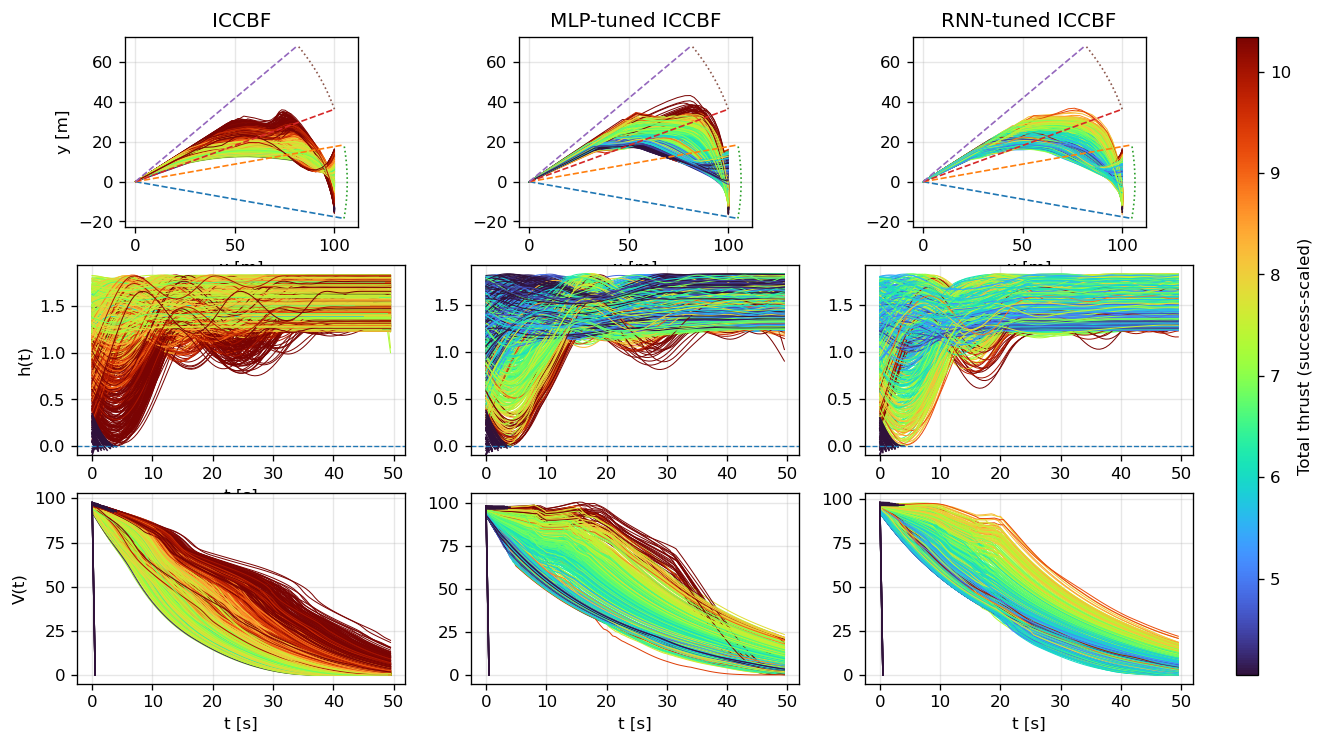

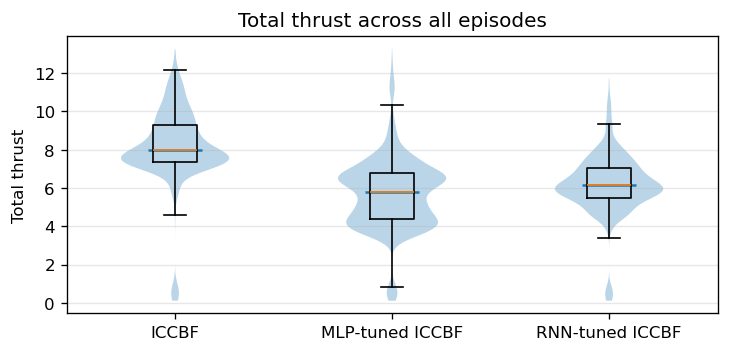

In [2]:
path_iccbf  = "../src/data/docking/Docking_noRL.mat"
path_stage1 = "../src/data/docking/Docking_NNfinal.mat"
path_rnn    = "../src/data/docking/Docking_RNN.mat"

from docking.plot_docking_results import plot_docking_threeway

out = plot_docking_threeway(
    baseline_mat=path_iccbf,
    mlp_mat=path_stage1,
    rnn_mat=path_rnn,
    save_prefix=None,   # or "figs/docking_levelX" to save PNGs
)

print(out["latex_table"])
print("success rates:", out["success_rates"])

## DA margin Validation


To validate the accuracy of the DA interval enclosures used in the sampled-data margin computation, a MC analysis is performed along complete trajectories. For each MC episode $e$ and each discrete time step $t=kT$, the DA polynomials are re-expanded locally about the current sampled state $\mathbf{x}_{e,k}$. For the margin calculation, using DA bounding over $\mathcal{B}(\mathbf{x}_{e,k},r)$, conservative interval enclosures $[\ell_{e,k},u_{e,k}]$ are computed for
$q \in \{\, b_N,\; L_f b_N,\; \boldsymbol{L}_g b_N\},$

For each quantity \(q\), the slack at episode  $e$ and time index $k$ is defined as
\begin{equation}
s_{e,k} \;=\; \min\!\big(q_{e,k}-\ell_{e,k},\;u_{e,k}-q_{e,k}\big),
\end{equation}
where $s_{e,k}<0$ indicates a violation of the DA enclosure. To capture worst-case behavior across the MC set at each time step, the minimum slack over episodes is computed as
\begin{equation}
s_k^{\min} \;=\; \min_{e}\, s_{e,k}.
\end{equation}
The validation results are summarized using violin plots of \(\{s_k^{\min}\}_{k=1}^{K}\) for each quantity \(q\). A strictly positive violin plot indicates that the DA interval bounds remain valid across all MC trajectories and time steps under the chosen $\mathcal{B}(\mathbf{x}_{e,k},r)$, providing empirical support that the DA-derived enclosures used to construct $\widehat{l}_{(\cdot)}(\mathbf{x}_k), \widehat{\Delta} \mathbf{x}_k$, and $\widehat{\nu}(T,\mathbf{x}_k)$ are conservative along the evaluated trajectories.


<p align="center">
  <img src="images/DockingDAapprox.png" alt="Distribution of distance to the computed upper and lower DA bounds for each quantity used to calculate the margin $\nu$, over all the MC episodes and all the time steps." width="55%"/>
</p>
